In [1]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset('2021.nc')
ds

<xarray.Dataset>
Dimensions:                      (time: 184, x: 1721, y: 411)
Coordinates:
  * time                         (time) datetime64[ns] 2021-05-01 ... 2021-10-31
  * x                            (x) float64 1.1 1.2 1.3 ... 172.9 173.0 173.1
  * y                            (y) float64 81.9 81.8 81.7 ... 41.1 41.0 40.9
    spatial_ref                  int64 ...
Data variables:
    Relative_Humidity_min        (time, y, x) float32 ...
    Precipitation_Flux           (time, y, x) float32 ...
    Temperature_Air_2m_Mean_24h  (time, y, x) float32 ...
    Wind_Speed_10m_Mean          (time, y, x) float32 ...
    Month                        (time) int64 ...
    FFMC                         (time, y, x) float64 ...
    DMC                          (time, y, x) float64 ...
    DC                           (time, y, x) float64 ...
Attributes:
    Conventions:  CF-1.7

In [5]:
from fwi_func import compute_isi, compute_bui, compute_fwi

In [7]:
isi = compute_isi(ds.Wind_Speed_10m_Mean, ds.FFMC)
bui = compute_bui(ds.DMC, ds.DC)
fwi = compute_fwi(isi, bui)
ds['FWI'] = (['time', 'y', 'x'], fwi)
ds

/Users/artembadmaev/IT/thesis/fwi/fwi_func.py:229: RuntimeWarning: invalid value encountered in power
  np.exp(2.72 * np.power(.434 * np.log(bb), .647)),


<xarray.Dataset>
Dimensions:                      (time: 184, x: 1721, y: 411)
Coordinates:
  * time                         (time) datetime64[ns] 2021-05-01 ... 2021-10-31
  * x                            (x) float64 1.1 1.2 1.3 ... 172.9 173.0 173.1
  * y                            (y) float64 81.9 81.8 81.7 ... 41.1 41.0 40.9
    spatial_ref                  int64 ...
Data variables:
    Relative_Humidity_min        (time, y, x) float32 ...
    Precipitation_Flux           (time, y, x) float32 ...
    Temperature_Air_2m_Mean_24h  (time, y, x) float32 ...
    Wind_Speed_10m_Mean          (time, y, x) float32 nan nan nan ... nan nan
    Month                        (time) int64 ...
    FFMC                         (time, y, x) float64 nan nan nan ... nan nan
    DMC                          (time, y, x) float64 nan nan nan ... nan nan
    DC                           (time, y, x) float64 nan nan nan ... nan nan
    FWI                          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    Conventions:  CF-1.7

In [17]:
ds.to_netcdf('data/fwi2021.nc')

In [12]:
import geopandas as gpd
import cartopy.crs as ccrs

In [13]:
geo = gpd.read_file('../regions.json')

In [14]:
ds_clip = ds.rio.clip(geo.geometry.values)
ds_clip = ds_clip.FWI.sel(time='2021-07-01')

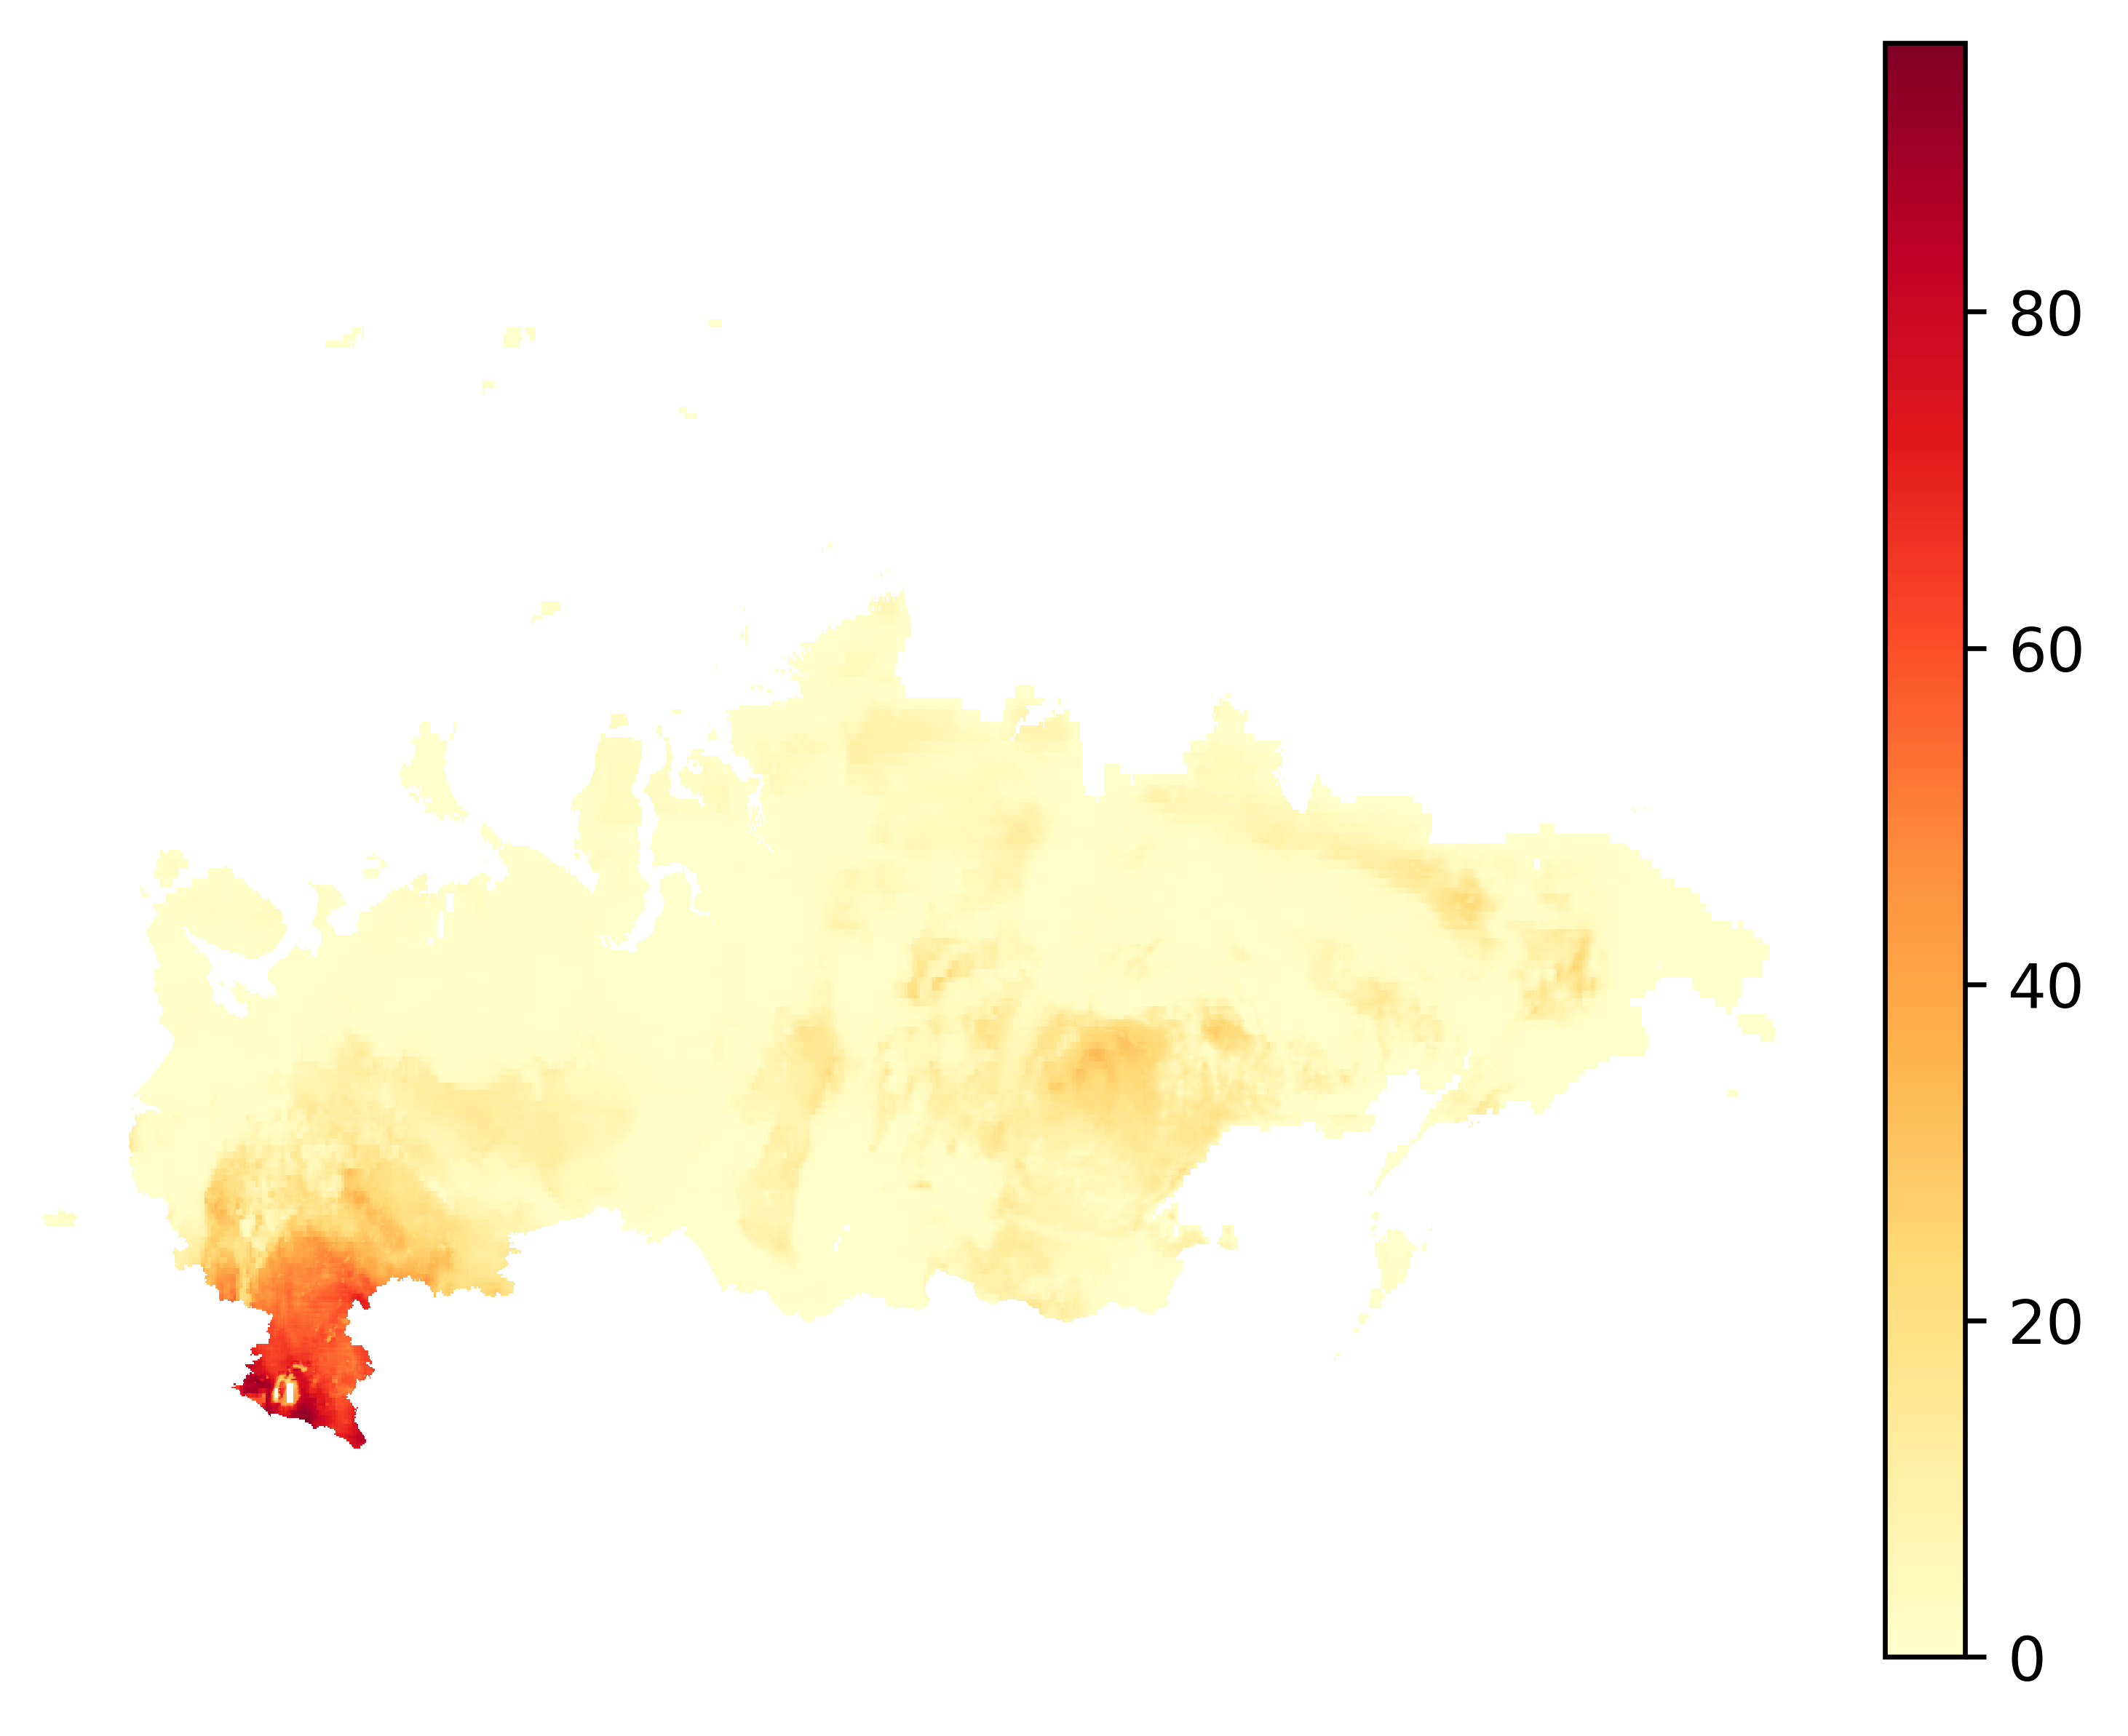

In [16]:
fig, ax = plt.subplots(
    subplot_kw={'projection':ccrs.Mercator(), 'frameon':False}, 
    dpi=600)

ds_clip.plot(
    transform=ccrs.PlateCarree(),
    add_labels=False, add_colorbar=True, cmap='YlOrRd', ax=ax)